<a href="https://colab.research.google.com/github/AvishekPritom/Pandas-learning-path/blob/main/Pandas07_How_to_reshape_the_layout_of_tables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
titanic = pd.read_csv("/content/titanic.csv")

In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Sort table rows

I want to sort the Titanic data according to the age of the passengers

In [ ]:
titanic.sort_values(by = 'Age').head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S


I want to sort the Titanic data according to the cabin class and age in descending order.

In [ ]:
titanic.sort_values(by = ['Pclass','Age'], ascending = False).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
280,281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
483,484,1,3,"Turkula, Mrs. (Hedwig)",female,63.0,0,0,4134,9.5875,NaN,S
326,327,0,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S


# Long to wide table format

In [ ]:
air_quality = pd.read_csv("/content/air_quality_long.csv")

In [ ]:
air_quality.head()

,city,country,date.utc,location,parameter,value,unit
0,Antwerpen,BE,2019-06-18 06:00:00+00:00,BETR801,pm25,18.0,µg/m³
1,Antwerpen,BE,2019-06-17 08:00:00+00:00,BETR801,pm25,6.5,µg/m³
2,Antwerpen,BE,2019-06-17 07:00:00+00:00,BETR801,pm25,18.5,µg/m³
3,Antwerpen,BE,2019-06-17 06:00:00+00:00,BETR801,pm25,16.0,µg/m³
4,Antwerpen,BE,2019-06-17 05:00:00+00:00,BETR801,pm25,7.5,µg/m³


Want to see from the titanic dataframe , select only the rows where Embarked equals to 'S'

In [ ]:
S = titanic[titanic['Embarked'] == 'S']

In [ ]:
S.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


Group the S data by "survived" and keep only the first 2 rows from each survived`

In [ ]:
S_subset = S.sort_index().groupby(['Survived']).head(2)

In [ ]:
S_subset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.250,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.050,NaN,S


Let’s use a small subset of the air quality data set. We focus on
𝑁⁢𝑂2
 data and only use the first two measurements of each location (i.e. the head of each group). The subset of data will be called no2_subset.

In [ ]:
no2 = air_quality[air_quality['parameter'] == 'no2']
# filter for no2 data only

In [ ]:
no2

,city,country,date.utc,location,parameter,value,unit
1825,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1826,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
1827,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
1828,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
1829,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³
...,...,...,...,...,...,...,...
5267,London,GB,2019-04-09 06:00:00+00:00,London Westminster,no2,41.0,µg/m³
5268,London,GB,2019-04-09 05:00:00+00:00,London Westminster,no2,41.0,µg/m³
5269,London,GB,2019-04-09 04:00:00+00:00,London Westminster,no2,41.0,µg/m³
5270,London,GB,2019-04-09 03:00:00+00:00,London Westminster,no2,67.0,µg/m³


 use 2 measurements (head) for each location (groupby)

In [ ]:
s_subset1 = no2.sort_index().groupby(['location']).head(2)

In [ ]:
s_subset1

,city,country,date.utc,location,parameter,value,unit
1825,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1826,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
3501,Antwerpen,BE,2019-06-17 08:00:00+00:00,BETR801,no2,41.0,µg/m³
3502,Antwerpen,BE,2019-06-17 07:00:00+00:00,BETR801,no2,45.0,µg/m³
3664,London,GB,2019-06-17 11:00:00+00:00,London Westminster,no2,11.0,µg/m³
3665,London,GB,2019-06-17 10:00:00+00:00,London Westminster,no2,11.0,µg/m³


I want the values for the three stations as separate columns next to each other.

In [ ]:
s_subset1.pivot(columns = 'location', values = 'value')

location,BETR801,FR04014,London Westminster
1825,NaN,20.0,NaN
1826,NaN,21.8,NaN
3501,41.0,NaN,NaN
3502,45.0,NaN,NaN
3664,NaN,NaN,11.0
3665,NaN,NaN,11.0


In [ ]:
no2.head()

,city,country,date.utc,location,parameter,value,unit
1825,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1826,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
1827,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
1828,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
1829,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³


<Axes: >

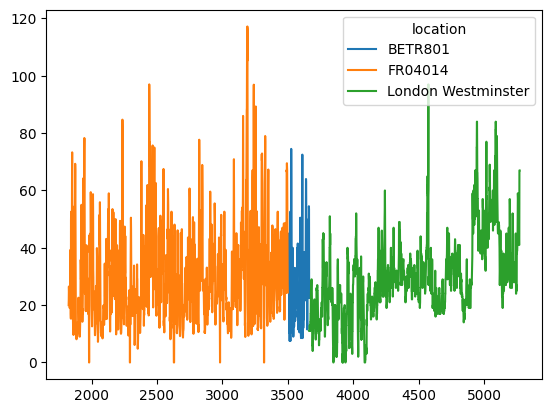

In [ ]:
no2.pivot(columns = 'location', values = 'value').plot()

#Pivot

I want the mean concentrations for
𝑁⁢𝑂2
 and
𝑃⁢𝑀2.5
 in each of the stations in table form.

In [ ]:
air_quality.pivot_table(values='value', index='location', columns='parameter', aggfunc='mean')

parameter,no2,pm25
location,,
BETR801,26.950920,23.169492
FR04014,29.374284,NaN
London Westminster,29.740050,13.443568


In the case of pivot(), the data is only rearranged. When multiple values need to be aggregated (in this specific case, the values on different time steps), pivot_table() can be used, providing an aggregation function (e.g. mean) on how to combine these values.

Pivot table is a well known concept in spreadsheet software. When interested in the row/column margins (subtotals) for each variable, set the margins parameter to True

#Wide to long format

In [ ]:
no2_wide = no2.pivot(index='date.utc', columns='location', values='value').reset_index()
no2 = no2_wide.melt(id_vars=['date.utc'], var_name='location', value_name='value')

The pandas.melt() method on a DataFrame converts the data table from wide format to long format. The column headers become the variable names in a newly created column.

The solution is the short version on how to apply pandas.melt(). The method will melt all columns NOT mentioned in id_vars together into two columns: A column with the column header names and a column with the values itself. The latter column gets by default the name value.

The additional parameters have the following effects:

value_vars defines which columns to melt together

value_name provides a custom column name for the values column instead of the default column name value

var_name provides a custom column name for the column collecting the column header names. Otherwise it takes the index name or a default variable

Hence, the arguments value_name and var_name are just user-defined names for the two generated columns. The columns to melt are defined by id_vars and value_vars.